In [30]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
class LinSet:
    def __init__(self, x_origin=None, facet = 5):
        self.x_origin = x_origin if x_origin is not None else np.array([0.0, 0.0])
        bias = np.random.rand()
        theta = np.linspace(bias, 2*np.pi+bias, facet+1)
        self.A = np.array([[np.cos(t), np.sin(t)] for t in theta])  # For polytope (H-representation)
        self.b = np.ones(facet+1) # For polytope

    def check_feasibility(self, x):
        """Check if point x is in the convex set"""
        x = np.array(x)
        return  x @ self.A.T - self.b

    def point_to_boundary_dist(self, u):
        """Find boundary distance along direction u from x0"""
        batch = u.shape[0]
        au = np.ones([batch,1]) * 10
        al = np.zeros([batch,1])
        x_origin = self.x_origin.copy()
        # Vectorized binary search for precise boundary
        while (au - al).max() > 1e-6:
            am = (au + al) / 2
            # Vectorized computation of all points
            points = x_origin + am * u
            # Vectorized feasibility check
            residual = self.check_feasibility(points)
            feasible_mask = residual.max(1, keepdims=True) < 0
            # Update bounds using boolean indexing
            al = np.where(feasible_mask, am, al)
            au = np.where(~feasible_mask, am, au)
        return al

class QuadSet:
    def __init__(self, x_origin=None, facet = 5):
        self.x_origin = x_origin if x_origin is not None else np.array([0.0, 0.0])
        bias = np.random.rand()
        theta = np.linspace(bias, 2*np.pi+bias, facet+1)
        self.A = [[np.cos(t), np.sin(t)] for t in theta]  # For polytope (H-representation)
        self.b = np.ones(facet+1) # For polytope

class StarSet:
    def __init__(self, x_origin=None, alpha=0.3, num_star=5):
        self.x_origin = x_origin if x_origin is not None else np.array([0.0, 0.0])
        self.alpha = alpha
        self.num_star = num_star
        
    def scaling(self, x):
        """Compute the scaling factor gamma for star-shaped set"""
        x = np.atleast_2d(x)
        # Handle points at origin
        norms = np.linalg.norm(x, axis=1, keepdims=True)
        mask = norms.flatten() > 1e-10
        
        scaling = np.ones((x.shape[0], 1))
        if np.any(mask):
            x_valid = x[mask]
            theta = np.arctan2(x_valid[:, 1], x_valid[:, 0])
            scaling[mask] = (1 + self.alpha * np.sin(self.num_star * theta)).reshape(-1, 1)
        
        return scaling
        
    def point_to_boundary_dist(self, u):
        """Find boundary distance along direction u from x_origin for star-shaped set"""
        u = np.atleast_2d(u)
        batch = u.shape[0]
        
        # For star-shaped sets, we can compute this analytically
        # The boundary is defined by r = scaling(θ) where θ = arctan2(u_y, u_x)
        theta = np.arctan2(u[:, 1], u[:, 0])
        boundary_scaling = 1 + self.alpha * np.sin(self.num_star * theta)
        
        # Distance from origin to boundary in direction u
        return boundary_scaling.reshape(-1, 1)


In [52]:
### Convex set only
class GaugeMap:
    def __init__(self, convex_set, p_norm=np.inf):
        """Initialize gauge map with a convex set and norm
        Args:
            convex_set: ConvexSet object defining the target space
            p_norm: The norm to use for scaling (default: inf-norm)
        """
        self.set = convex_set
        self.p_norm = p_norm
    
    def forward(self, z):
        """Map points from unit ball to convex set"""
        scaling = self._compute_scaling(z, forward=True)
        return scaling * z + self.set.x_origin
    
    def inverse(self, x):
        """Map points from convex set to unit ball"""
        x_shifted = x - self.set.x_origin
        scaling = self._compute_scaling(x_shifted, forward=False)
        return scaling * x_shifted
    
    def _compute_scaling(self, x, forward=True):
        """Calculate scaling factor for gauge function and its inverse"""
        x_norm = np.linalg.norm(x, axis=1, ord=2, keepdims=True)
        z_norm = np.linalg.norm(x, axis=1, ord=self.p_norm, keepdims=True)
        
        # Avoid division by zero
        mask = x_norm > 1e-10
        u_dir = np.zeros_like(x)
        u_dir[mask.flatten()] = x[mask.flatten()] / x_norm[mask.flatten()]
        
        # Get boundary distances
        boundary_dist = self.set.point_to_boundary_dist(u_dir)
        
        if forward:
            scaling = np.where(mask, z_norm / x_norm * boundary_dist, 0)
        else:
            scaling = np.where(mask, x_norm / (z_norm * boundary_dist + 1e-10), 0)
        
        return scaling

### Star-convex set homeomorphism
class StarGaugeMap:
    def __init__(self, star_set, p_norm=2):
        """Initialize star gauge map
        Args:
            star_set: StarSet object defining the target space
            p_norm: The norm to use for scaling (default: 2-norm)
        """
        self.set = star_set
        self.p_norm = p_norm
    
    def forward(self, z):
        """Map points from unit ball to star-shaped set"""
        z = np.atleast_2d(z)
        return z * self.set.scaling(z) + self.set.x_origin
    
    def inverse(self, x):
        """Map points from star-shaped set to unit ball"""
        x = np.atleast_2d(x)
        x_shifted = x - self.set.x_origin
        return x_shifted / self.set.scaling(x_shifted)

### INN-based homeomorphism
class INNMap:
    def __init__(self, non_convex_set, p_norm=np.inf):
        """Initialize gauge map with a convex set and norm
        Args:
            convex_set: ConvexSet object defining the target space
            p_norm: The norm to use for scaling
        """
        self.set = non_convex_set
        self.p_norm = p_norm

In [60]:
# =====================
# Star-Convex Set Visualization Example
# =====================

def visualize_star_convex_mapping(alpha=0.3, num_star=5):
    """
    Visualize the mapping between a star-convex set and unit ball
    """
    # Create star-shaped set
    star_set = StarSet(alpha=alpha, num_star=num_star)
    star_gauge = StarGaugeMap(star_set)
    
    # Generate boundary points for star-shaped set using angular parameterization
    n_points_per_segment = 100
    theta_full = np.linspace(0, 2*np.pi, n_points_per_segment * num_star, endpoint=False)
    
    # For star-shaped sets, we sample along rays from the origin
    # The boundary is at distance scaling(θ) from origin in direction θ
    star_boundary_points = []
    colors_star = []
    
    # Create different colored segments based on star pattern
    n_segments = num_star * 2  # More segments for better visualization
    segment_colors = plt.cm.rainbow(np.linspace(0, 1, n_segments))
    
    for i in range(n_segments):
        # Define angular range for this segment
        theta_start = i * 2 * np.pi / n_segments
        theta_end = (i + 1) * 2 * np.pi / n_segments
        theta_segment = np.linspace(theta_start, theta_end, n_points_per_segment)
        
        # Compute boundary points for this segment
        boundary_scaling = 1 + alpha * np.sin(num_star * theta_segment)
        x_segment = boundary_scaling * np.cos(theta_segment)
        y_segment = boundary_scaling * np.sin(theta_segment)
        segment_points = np.column_stack([x_segment, y_segment])
        
        star_boundary_points.append(segment_points)
        colors_star.append(segment_colors[i])
    
    # Visualize results
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Star-shaped set boundary with different colors
    plt.subplot(1, 2, 1)
    for i, (points, color) in enumerate(zip(star_boundary_points, colors_star)):
        plt.plot(points[:, 0], points[:, 1], '-', color=color, 
                label=f'Segment {i+1}' if i < 5 else '', linewidth=2, alpha=0.95)
    
    plt.title(f'Star-Shaped Set (α={alpha}, n={num_star})', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    xlim = 2.0
    plt.xlim([-xlim, xlim])
    plt.ylim([-xlim, xlim])
    
    # Plot 2: Mapped points on unit ball with corresponding colors
    plt.subplot(1, 2, 2)
    for i, (points, color) in enumerate(zip(star_boundary_points, colors_star)):
        # Map star boundary points to unit ball
        ball_points = star_gauge.inverse(points)
        plt.plot(ball_points[:, 0], ball_points[:, 1], '-', color=color, 
                label=f'Mapped Segment {i+1}' if i < 5 else '', linewidth=2, alpha=0.95)
    
    # Add unit circle for reference
    # circle_theta = np.linspace(0, 2*np.pi, 200)
    # unit_circle_x = np.cos(circle_theta)
    # unit_circle_y = np.sin(circle_theta)
    # plt.plot(unit_circle_x, unit_circle_y, 'k--', alpha=0.5, linewidth=1, label='Unit Circle')
    
    plt.title('Mapped to Unit Ball', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    
    plt.tight_layout()
    plt.show()
    
    return star_set, star_gauge

In [61]:
# =====================
# Enhanced Polytope Visualization (Fixed)
# =====================

def visualize_polytope_mapping(facets=5):
    """
    Visualize the mapping between a polytope and unit ball
    """
    # Create polytope
    Polytope = LinSet(facet=facets)
    gauge = GaugeMap(Polytope,  p_norm = 2)
    
    # Sample points from each facet
    A = np.array(Polytope.A)
    b = np.array(Polytope.b)
    n_points_per_facet = 100
    
    xlim = 1.5
    x = np.linspace(-xlim, xlim, n_points_per_facet)
    facet_points_list = []
    
    for i in range(len(A)):
        # Check if A[i,1] is not zero to avoid division by zero
        if abs(A[i, 1]) > 1e-10:
            y = -(A[i, 0] * x - b[i]) / A[i, 1]
        else:
            # Handle vertical lines
            y = np.linspace(-xlim, xlim, n_points_per_facet)
            x_const = np.full_like(y, b[i] / A[i, 0] if abs(A[i, 0]) > 1e-10 else 0)
            facet_points_list.append(np.stack([x_const, y], axis=1))
            continue
        facet_points_list.append(np.stack([x, y], axis=1))
    
    n_facets = len(A)
    colors = plt.cm.rainbow(np.linspace(0, 1, n_facets))
    
    # Visualize results
    plt.figure(figsize=(12, 5))
    
    # Plot polygon facets with different colors
    plt.subplot(1, 2, 1)
    for i, points in enumerate(facet_points_list):
        plt.plot(points[:, 0], points[:, 1], '-', color=colors[i], 
                label=f'Facet {i+1}', linewidth=2, alpha=0.95)
    plt.title(f'Polytope Facets (n={facets})', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.xlim([-xlim, xlim])
    plt.ylim([-xlim, xlim])
    
    # Plot mapped points on unit ball with corresponding colors
    plt.subplot(1, 2, 2)
    for i, points in enumerate(facet_points_list):
        ball_points = gauge.inverse(points)
        plt.plot(ball_points[:, 0], ball_points[:, 1], '-', color=colors[i], 
                label=f'Mapped Facet {i+1}', linewidth=2, alpha=0.95)
    
    # # Add unit circle for reference
    # circle_theta = np.linspace(0, 2*np.pi, 200)
    # unit_circle_x = np.cos(circle_theta)
    # unit_circle_y = np.sin(circle_theta)
    # plt.plot(unit_circle_x, unit_circle_y, 'k--', alpha=0.5, linewidth=1, label='Unit Circle')
    
    plt.title('Mapped to Unit Ball', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.xlim([-xlim, xlim])
    plt.ylim([-xlim, xlim])
    
    plt.tight_layout()
    plt.show()
    
    return Polytope, gauge


=== Gauge Mapping Visualizations ===

1. Polytope Mapping:


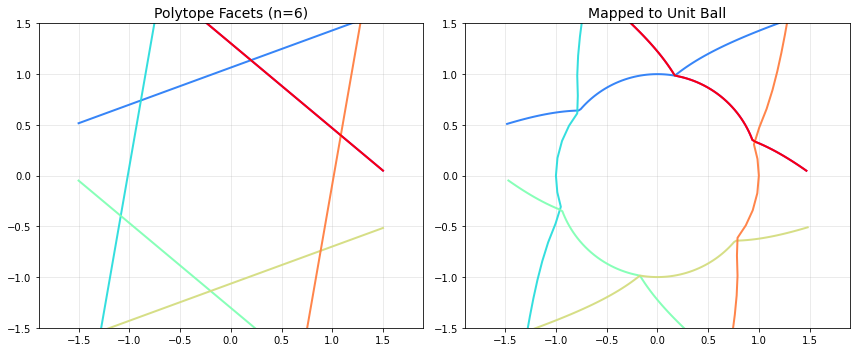


2. Star-Convex Mapping:


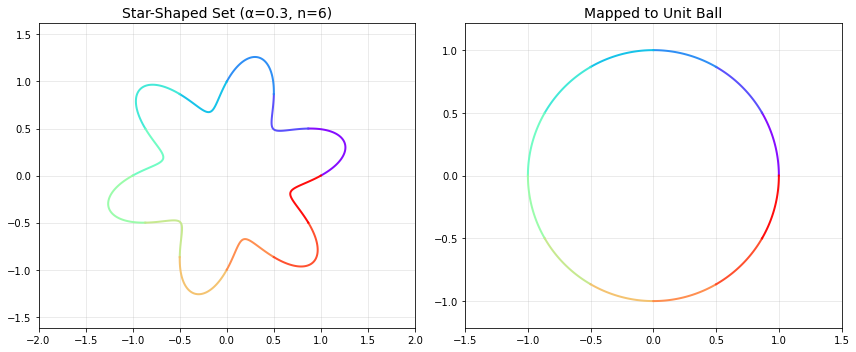

In [63]:

# Run demonstrations
if __name__ == "__main__":
    print("=== Gauge Mapping Visualizations ===")
    print("\n1. Polytope Mapping:")
    visualize_polytope_mapping(facets=6)
    
    print("\n2. Star-Convex Mapping:")
    visualize_star_convex_mapping(alpha=0.3, num_star=6)

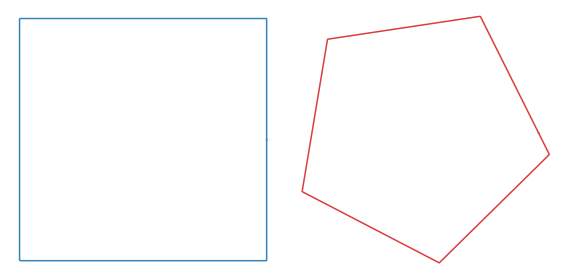

In [49]:
# =====================
# Visualization Example
# =====================
if __name__ == "__main__":
    # Create hexagon (using numerical boundary detection)
    Polytope = LinSet(facet = 5)
    # Map points through gauge mappings
    N = 10000
    p_norm = np.inf
    gauge = GaugeMap(Polytope, p_norm=p_norm)
    init_dis = ['uniform', 'gaussian', 'two_gaussians'][0]
    # create distribution over ball
    if init_dis == 'uniform':
        ball_points = np.random.uniform(-1,1, (N,2))
    elif init_dis == 'gaussian':
        ball_points = np.random.randn(N,2)
    else:
        ball_points = np.concatenate([ np.random.randn(N,2)/4-np.array([0.5,0.5]),
                                       np.random.randn(N,2)/4+np.array([0.5,0.5]),], axis=0)
    radius = np.linalg.norm(ball_points, axis=1, ord=p_norm)
    ball_points = ball_points[radius<=1]
    poly_points = gauge.forward(ball_points)

    # sampling boundary
    theta = np.linspace(0,1,1000) * np.pi * 2
    ball_boundary = np.stack([np.cos(theta), np.sin(theta)],axis=1)
    radius = np.linalg.norm(ball_boundary, axis=1, ord=p_norm, keepdims=True)
    ball_boundary = ball_boundary / (radius+1e-8)
    poly_boudanry = gauge.forward(ball_boundary)
    
    # Visualize results
    plt.figure(figsize=(8, 4))
    # Plot hexagon mapping
    plt.subplot(1, 2, 1)
    # plt.scatter(ball_points[:,0], ball_points[:,1], marker='o', s=20, linewidths=0, alpha=0.25, c='C0', label='Unit ball')
    plt.plot(ball_boundary[:,0], ball_boundary[:,1], alpha=0.9, c='C0')
    plt.axis('off')
    # plt.title("Samples within unit ball")
    plt.subplot(1, 2, 2)
    # plt.scatter(poly_points[:,0], poly_points[:,1], marker='o', s=20, linewidths=0, alpha=0.25, c='C3', label='Poly distribution')
    plt.plot(poly_boudanry[:,0], poly_boudanry[:,1],alpha=0.9,  c='C3')
    # plt.title("Samples within polytope")
    plt.axis('off')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()